<a id="1"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Imports</center></h1>




# Imports

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import shutil
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import random

import scipy as sp
import itertools

from scipy import ndimage
from shutil import copyfile, rmtree



In [2]:
!pip install kagglehub -q

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rayhanadi/yolo-formatted-mp-idb-malaria-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/arulipn/.cache/kagglehub/datasets/rayhanadi/yolo-formatted-mp-idb-malaria-dataset/versions/1


In [4]:
!ls -al /home/arulipn/.cache/kagglehub/datasets/rayhanadi/yolo-formatted-mp-idb-malaria-dataset/versions/1/MP-IDB-YOLO/

total 36
drwxrwsr-x 4 arulipn users  4096 Mar 17 11:58 .
drwxrwsr-x 3 arulipn users  4096 Mar 17 11:58 ..
-rw-rw-r-- 1 arulipn users   206 Mar 17 11:58 data.yaml
drwxrwsr-x 2 arulipn users 12288 Mar 17 11:58 images
drwxrwsr-x 2 arulipn users 12288 Mar 17 11:58 labels


In [5]:
!pip install ultralytics -q

In [6]:


import yaml
import cv2
import torch
torch.cuda.empty_cache()
# Optional: aggressive clear
import gc; gc.collect(); torch.cuda.empty_cache()
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
!export CUDA_VISIBLE_DEVICES=1

from sklearn.model_selection import train_test_split
from ultralytics import YOLO
from IPython.display import Image, display
import random

# Checking GPU Availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 1. Preparing the data structure ==============================================

# Source paths (Kaggle input)
input_base = "/home/arulipn/.cache/kagglehub/datasets/rayhanadi/yolo-formatted-mp-idb-malaria-dataset/versions/1/MP-IDB-YOLO"
all_images_dir = os.path.join(input_base, "images")
all_labels_dir = os.path.join(input_base, "labels")

# Working directories (Kaggle working)
working_base = "/tmp/MP-IDB-YOLO"
os.makedirs(working_base, exist_ok=True)

# Create a folder structure
train_img_dir = os.path.join(working_base, "images/train")
val_img_dir = os.path.join(working_base, "images/val")
train_label_dir = os.path.join(working_base, "labels/train")
val_label_dir = os.path.join(working_base, "labels/val")

for dir_path in [train_img_dir, val_img_dir, train_label_dir, val_label_dir]:
    os.makedirs(dir_path, exist_ok=True)

# Data separation
image_files = [f for f in os.listdir(all_images_dir) if f.lower().endswith(('.jpg', '.png'))]
train_files, val_files = train_test_split(image_files, test_size=0.2, random_state=42)

# Copying files
def copy_files(files, src_img_dir, src_label_dir, dst_img_dir, dst_label_dir):
    for img_file in files:
        # Copying the image
        shutil.copy(
            os.path.join(src_img_dir, img_file),
            os.path.join(dst_img_dir, img_file))
        
        # Copy the corresponding label
        label_file = os.path.splitext(img_file)[0] + '.txt'
        shutil.copy(
            os.path.join(src_label_dir, label_file),
            os.path.join(dst_label_dir, label_file))

copy_files(train_files, all_images_dir, all_labels_dir, train_img_dir, train_label_dir)
copy_files(val_files, all_images_dir, all_labels_dir, val_img_dir, val_label_dir)

# Convert all classes to single "parasite" class (0)
def convert_to_single_class(labels_dir):
    for label_file in os.listdir(labels_dir):
        with open(os.path.join(labels_dir, label_file), 'r') as f:
            lines = [line for line in f if line.strip()]  # Keep all segmentation masks
        
        # Convert all class IDs to 0
        new_lines = []
        for line in lines:
            parts = line.split()
            parts[0] = '0'  # Change class ID to 0
            new_lines.append(" ".join(parts) + "\n")
        
        with open(os.path.join(labels_dir, label_file), 'w') as f:
            f.writelines(new_lines)

# Apply conversion to all labels
convert_to_single_class(train_label_dir)
convert_to_single_class(val_label_dir)

# Create data.yaml with one class
yaml_content = f"""
train: {train_img_dir}/
val: {val_img_dir}/
nc: 1  # Only detect presence/absence
names: ['parasite']
"""

DATA_YAML_PATH = os.path.join(working_base, "data.yaml")
with open(DATA_YAML_PATH, "w") as f:
    f.write(yaml_content)

print(f"\nDataset prepared at: {working_base}")
print(f"Train images: {len(train_files)}")
print(f"Val images: {len(val_files)}")
print("Number of classes: 1 (parasite)")


Using device: cuda

Dataset prepared at: /tmp/MP-IDB-YOLO
Train images: 167
Val images: 42
Number of classes: 1 (parasite)


In [7]:

# 2. Checking the data structure ===============================================

def check_dataset_structure(yaml_path):
    with open(yaml_path) as f:
        data = yaml.safe_load(f)
    
    print("\nDataset info:")
    print(f"Classes: {data['names']}")
    print(f"Number of classes: {data['nc']}")
    
    # Checking the number of files
    train_count = len(os.listdir(data['train']))
    val_count = len(os.listdir(data['val']))
    
    print(f"Training images: {train_count}")
    print(f"Validation images: {val_count}")
    
    # Checking images and labels compliance
    train_labels = os.path.dirname(data['train']).replace('images', 'labels')
    train_label_count = len(os.listdir(train_labels))
    print(f"Training labels: {train_label_count} (should match images)")
    
    return data

dataset_info = check_dataset_structure(DATA_YAML_PATH)




Dataset info:
Classes: ['parasite']
Number of classes: 1
Training images: 167
Validation images: 42
Training labels: 167 (should match images)



Class distribution in training set:
parasite: 1102 instances


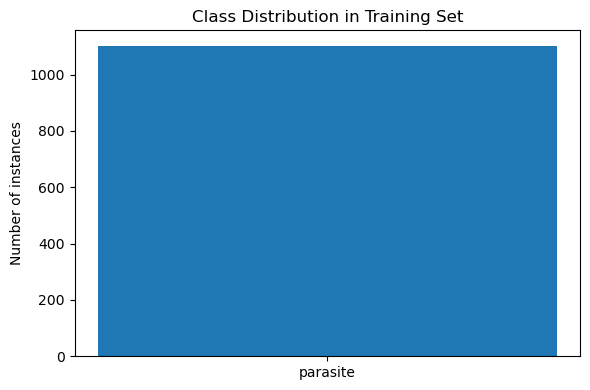

In [8]:
# 3. Class distribution analysis ===========================================

def analyze_class_distribution(labels_dir):
    class_counts = {0: 0}  # Only parasite class
    
    for label_file in os.listdir(labels_dir):
        with open(os.path.join(labels_dir, label_file), 'r') as f:
            lines = f.readlines()
            for line in lines:
                class_id = int(line.split()[0])
                class_counts[class_id] += 1
    
    print("\nClass distribution in training set:")
    print(f"parasite: {class_counts[0]} instances")
    
    # Distribution visualization
    plt.figure(figsize=(6, 4))
    plt.bar(['parasite'], [class_counts[0]])
    plt.title("Class Distribution in Training Set")
    plt.ylabel("Number of instances")
    plt.tight_layout()
    plt.show()
    
    return class_counts

class_distribution = analyze_class_distribution(train_label_dir)



In [9]:
# 4. Optimized Model Training ==============================================

MODEL_NAME = "yolo11n-seg"  # Using YOLO11n-seg
EPOCHS = 100
IMGSZ = 640
BATCH_SIZE = 4  # Reduce if you get CUDA OOM errors
CONF_THRES = 0.3

# Load model with segmentation-specific settings
model = YOLO(f"{MODEL_NAME}.pt").to(device)

def train_model():
    results = model.train(
        data=DATA_YAML_PATH,
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH_SIZE,
        name=f'{MODEL_NAME}_malaria_seg_optimized',
        patience=15,
        save=True,
        save_period=10,
        device=device,
        workers=1,  # Reduced for stability
        exist_ok=True,
        optimizer='AdamW',
        lr0=0.001,
        augment=True,  # Keep for training
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=45,
        scale=0.5,
        flipud=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.1,  # Reduced for segmentation
        copy_paste=0.1,  # Reduced for segmentation
        overlap_mask=True,
        mask_ratio=4,
        single_cls=True,
        close_mosaic=10,  # Disable mosaic in last epochs
        pretrained=True
    )
    return results

print("\nStarting optimized training...")
train_results = train_model()




Starting optimized training...
Ultralytics 8.4.23 🚀 Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA H100 NVL, 95346MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tmp/MP-IDB-YOLO/data.yaml, degrees=45, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n-seg_malaria_seg_optimized, nbs=64, nms=False, opset=None, optimize=False,

In [13]:
# 5. Optimized Validation =================================================

def validate_model():
    metrics = model.val(
        data=DATA_YAML_PATH,
        batch=BATCH_SIZE,
        imgsz=IMGSZ,
        conf=0.25,
        iou=0.45,
        device=device,
        split='val',
        mask_ratio=4,
        augment=False,  # Explicitly disable for validation
        plots=True,
        save_json=True,
        save_hybrid=True  # Saves both boxes and masks
    )
    
    print("\nOptimized Validation metrics:")
    print(f"Box mAP50-95: {metrics.box.map:.4f}")
    print(f"Box mAP50: {metrics.box.map50:.4f}")
    print(f"Mask mAP50-95: {metrics.seg.map:.4f}")
    print(f"Mask mAP50: {metrics.seg.map50:.4f}")
    
    return metrics

val_metrics = validate_model()



WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.23 🚀 Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA H100 NVL, 95346MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6253.5±3222.1 MB/s, size: 3379.8 KB)
val: Scanning /tmp/MP-IDB-YOLO/labels/val.cache... 42 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 42/42 12.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 7.3it/s 1.5s.3s
                   all         42        334      0.814       0.76      0.824      0.511      0.828      0.766      0.829       0.41
Speed: 0.4ms preprocess, 6.1ms inference, 0.0ms loss, 2.3ms postprocess per image
Saving /home/arulipn/runs/segment/val2/predictions.json...
Results saved to /home/arulipn/runs/segment/val2

Optimized Validation metrics:
Box mAP50-95: 0.5111
Box mAP50: 0.8244
Mask mAP50-95: 0.4104
Mask mAP50: 0.8288



image 1/1 /tmp/MP-IDB-YOLO/images/val/1707180816-0019-S.jpg: 480x640 1 item, 6.9ms
Speed: 2.5ms preprocess, 6.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


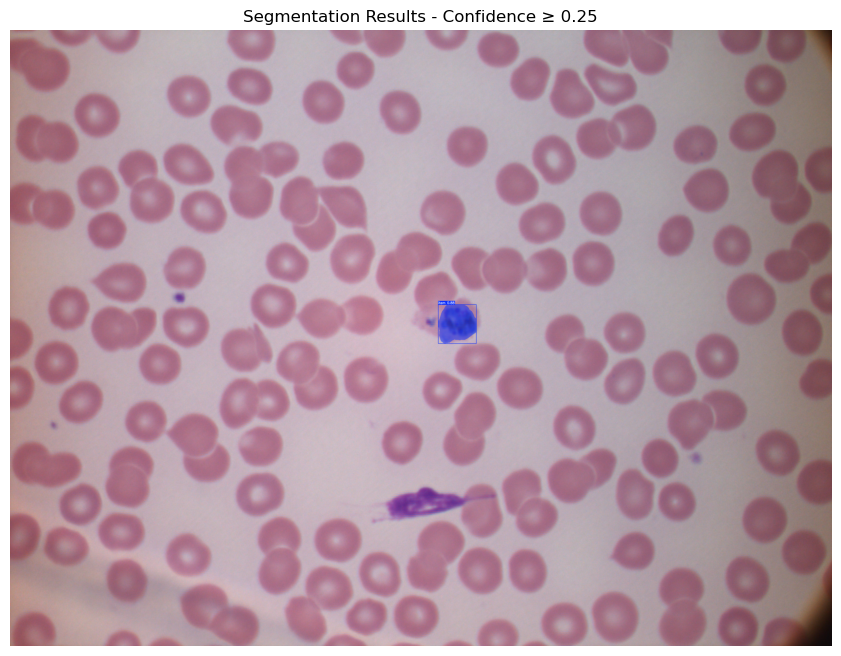


Detailed analysis for 1707180816-0019-S.jpg:
Detection 1:
- Class: item
- Confidence: 0.8790
- BBox coordinates: [1350.5426025390625, 866.62353515625, 1470.1787109375, 989.1975708007812]
- Mask area (pixels): 11753


In [15]:
# 6. Enhanced Visualization ===============================================

def predict_and_visualize(image_path, conf_thres=CONF_THRES):
    """Enhanced segmentation visualization"""
    if not os.path.exists(image_path):
        print(f"Error: Image not found - {image_path}")
        return None
    
    results = model.predict(
        source=image_path,
        conf=conf_thres,
        imgsz=IMGSZ,
        device=device,
        retina_masks=True,
        augment=False,  # Disable TTA
        stream=False,   # For better memory handling
        max_det=50      # Limit detections per image
    )
    
    for r in results:
        # Plot with masks and boxes
        im_array = r.plot(
            conf=True,
            labels=True,
            boxes=True,
            masks=True,
            line_width=1,
            font_size=10
        )
        im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(12, 8))
        plt.imshow(im_rgb)
        plt.axis('off')
        plt.title(f"Segmentation Results - Confidence ≥ {conf_thres}")
        plt.show()
        
        # Detailed mask analysis
        print(f"\nDetailed analysis for {os.path.basename(image_path)}:")
        for i, (box, mask) in enumerate(zip(r.boxes, r.masks)):
            cls_id = int(box.cls)
            cls_name = model.names[cls_id]
            conf = box.conf.item()
            xyxy = box.xyxy[0].tolist()
            mask_area = mask.data.sum().item()
            
            print(f"Detection {i+1}:")
            print(f"- Class: {cls_name}")
            print(f"- Confidence: {conf:.4f}")
            print(f"- BBox coordinates: {xyxy}")
            print(f"- Mask area (pixels): {mask_area}")
    
    return results

# Example prediction
val_images = os.listdir(val_img_dir)
if val_images:
    sample_image = os.path.join(val_img_dir, random.choice(val_images))
    predict_and_visualize(sample_image, conf_thres=0.25)  # Lower threshold for demo
else:
    print("No validation images found")



In [12]:
# 7. Export with Optimization ============================================

print("\nExporting optimized model...")
try:
    export_success = model.export(
        format="onnx",
        imgsz=IMGSZ,
        simplify=True,  # ONNX simplifier
        dynamic=False,  # Fixed batch size for better performance
        opset=12
    )
    if export_success:
        print("Model successfully exported with optimizations")
    else:
        print("Export failed")
except Exception as e:
    print(f"Export error: {str(e)}")

print("\nOptimized pipeline completed!")


Exporting optimized model...
Ultralytics 8.4.23 🚀 Python-3.12.9 torch-2.6.0+cu124 CPU (Intel Xeon Gold 6438Y+)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/home/arulipn/runs/segment/yolo11n-seg_malaria_seg_optimized/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 37, 8400), (1, 32, 160, 160)) (5.7 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/17.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━ 7.3/17.5 MB 60.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━ 14.4/17.5 MB 42.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/252.8 MB ? eta -:--:--
   ━╺━━━━━━━━━━━━━━━━━━━━

<a id="2"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Data Preprocessing</center></h1>
    
# Data Preprocessing


**Let's check the distribution of the data**

**Now let's call the function to create the  training/validation data**

**As a sanity check let's check the data directories**

<a name="2-2"></a>

## Create Generators

**Now let's make sure we got the correct data**

**Great, now that the data is ready let's train our model**

<a id="3"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Model</center></h1>
    
# Model


<a id="4"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Evaluation</center></h1>
    
# Evaluation


<a name="4-1"></a>

## Evaluate the model on the test set



**Let's try using data augmentation**

<a id="5"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Trying Data Augmentation </center></h1>

# Trying Data Augmentation 

<a id="5"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Conclusion </center></h1>

# Conclusion 

**Using data augmentation with these hyper-parameters gave us worse results**


**We can Use [transfer learning](https://www.kaggle.com/code/fareselmenshawii/introdution-to-transfer-learning/edit/run/109466477) or a more complex architecture to solve this problem**

**We'll discuss these topics in later notebooks**

<a id="7"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Thank You </center></h1>


    
# Thank You

**Thank you for taking your time and going through this notebook**

**Please let me know if you have any feedback**